# EEG Pipeline with MNE-Python

A beginner-friendly EEG preprocessig and ERP analysis pipeline built with MNE-Python, using synthetic data.

** Author: ** Rey
** Dataset: ** Synthetic (generated with numpy)
** Goal: ** Learn the Raw --> Epochs --> Evoked workflow

In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Check MNE is working
mne.sys_info()

Platform             Windows-10-10.0.26100-SP0
Python               3.8.20 (default, Oct  3 2024, 15:19:54) [MSC v.1929 64 bit (AMD64)]
Executable           C:\Users\ASUS\miniconda3\envs\my_env\python.exe
CPU                  Intel64 Family 6 Model 142 Stepping 12, GenuineIntel (4 cores)
Memory               3.8 GB

Core
├☒ mne               1.6.1 (outdated, release 1.12.1 is available!)
├☑ numpy             1.24.4 (unknown linalg bindings (threadpoolctl module not found: No module named 'threadpoolctl'))
├☑ scipy             1.10.1
├☑ matplotlib        3.7.5 (backend=module://matplotlib_inline.backend_inline)
├☑ pooch             1.8.2
└☑ jinja2            3.1.4

Numerical (optional)
├☑ pandas            2.0.3
└☐ unavailable       sklearn, numba, nibabel, nilearn, dipy, openmeeg, cupy

Visualization (optional)
├☑ qtpy              2.4.1 (PyQt5=5.15.2)
├☑ ipywidgets        8.1.2
└☐ unavailable       pyvista, pyvistaqt, vtk, ipympl, pyqtgraph, mne-qt-browser, trame_client, trame_server,

## Step 1- Create Synthetic EEG data

We simulate 64-channel EEG at 1000 Hz for 60 seconds.
No download needed - this lets us learn the MNE workflow before working with real data.

In [7]:
# Create channel metadata 
info = mne.create_info(
    ch_names=[f'EEG{i:03}' for i in range(64)],
    sfreq=1000, #sampling rate - by defining this, MNE automatically set high and lowp.
    ch_types='eeg'
)

# Simulate random EEG signal
np.random.seed(42)
data= np.random.randn(64, 60000) * 10e-6

# Wrap into Raw object
raw=mne.io.RawArray(data,info)
print(raw.info)

# Highpass: 0.0 and lowpass: 500.0 confirm the data is completely unfiltered.

Creating RawArray with float64 data, n_channels=64, n_times=60000
    Range : 0 ... 59999 =      0.000 ...    59.999 secs
Ready.
<Info | 7 non-empty values
 bads: []
 ch_names: EEG000, EEG001, EEG002, EEG003, EEG004, EEG005, EEG006, EEG007, ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 1000.0 Hz
>


## Step 2 - Filter the Signal

We apply a bandpass filter (0.1 - 40 Hz) to:
- Remove slow drifts below 0.1 Hz (DC offset, sweat artifacts)
- Remove high-frequency noise above 40 Hz (muscle artifacts)

This is standard practice for ERP analysis.

In [8]:
# Apply bandpass filter
raw.filter(l_freq=0.1, h_freq=40.0)

# Confirm filter was applied
print(f"Highpass: {raw.info['highpass']} Hz")
print(f"Lowpass: {raw.info['lowpass']} Hz")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)

Highpass: 0.1 Hz
Lowpass: 40.0 Hz


## Step 3 - Creating Events and Epochs

In real EEG experiments, events are triggers sent to the amplifier marking when a stimulus occured (e.g. an image appeared on screen).

Here we simulate 100 random events to practice the epoching workflow.
Epochs are time-locked segments of EEG cut around each event:
- 200ms before the event (baseline period)
- 800ms after the event (response window)

In [9]:
# Simulate 100 event triggers at random timepoints
np.random.seed(42) # with 42 the results are reproducible, it always gives 51,92,14,71,60
n_events = 100

# Choose random timepoints - avoid the first and last second
event_samples = np.sort(np.random.choice(
    np.arange(1000, 59000), n_events, replace=False
))

# Build the events array — 3 columns:
# [sample_index, previous_event_id, event_id]
events = np.column_stack([
    event_samples,
    np.zeros(n_events, dtype=int),
    np.ones(n_events, dtype=int)
])

print(f"Number of events: {len(events)}")
print(f"First 5 events:\n{events[:5]}")

# Interpretation of the output:


#    1224 Sample index, when the event occured - divided by sampling rate = time : 1.224 s
 #   0 Previous event ID, always 0 for simulated data
  #  1 Event ID, the condition label - stimulus

Number of events: 100
First 5 events:
[[1224    0    1]
 [1273    0    1]
 [2227    0    1]
 [2638    0    1]
 [3558    0    1]]


## Step 4 — Epoch the Data

We cut the continuous signal into 1-second segments around each event.
Each epoch runs from -200ms (baseline) to +800ms (response window).
Baseline correction subtracts the average pre-stimulus activity from the entire epoch, removing slow drifts and DC offset.

In [10]:
# Cut continuous data into epochs around events
epochs = mne.Epochs(
    raw,                          # the filtered continuous data
    events,                       # our 100 simulated events
    event_id={'stimulus': 1},     # label event ID 1 as 'stimulus'
    tmin=-0.2,                    # start 200ms before event
    tmax=0.8,                     # end 800ms after event
    baseline=(-0.2, 0),           # baseline: use -200ms to 0ms
    preload=True                  # load all epochs into memory now
)

print(epochs)
print(f"\nEpoch shape: {epochs.get_data().shape}")
print(f"Time points: {len(epochs.times)}")
print(f"First timepoint: {epochs.times[0]:.3f}s")
print(f"Last timepoint: {epochs.times[-1]:.3f}s")

Not setting metadata
100 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 100 events and 1001 original time points ...
0 bad epochs dropped
<Epochs |  100 events (all good), -0.2 – 0.8 s, baseline -0.2 – 0 s, ~48.9 MB, data loaded,
 'stimulus': 100>

Epoch shape: (100, 64, 1001)
Time points: 1001
First timepoint: -0.200s
Last timepoint: 0.800s


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5936\2327002723.py:13: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  print(f"\nEpoch shape: {epochs.get_data().shape}")


## Step 5 — Artifact Rejection

We remove epochs contaminated by artifacts — large voltage deflections
caused by eye blinks, muscle tension, or electrode movement.

Any epoch where a channel exceeds 150µV peak-to-peak is rejected.
With synthetic random data, few or no epochs will be rejected.
In real EEG, typically 10–30% of epochs are removed at this stage.

Epochs before rejection: 100
0 bad epochs dropped
Epochs after rejection: 100


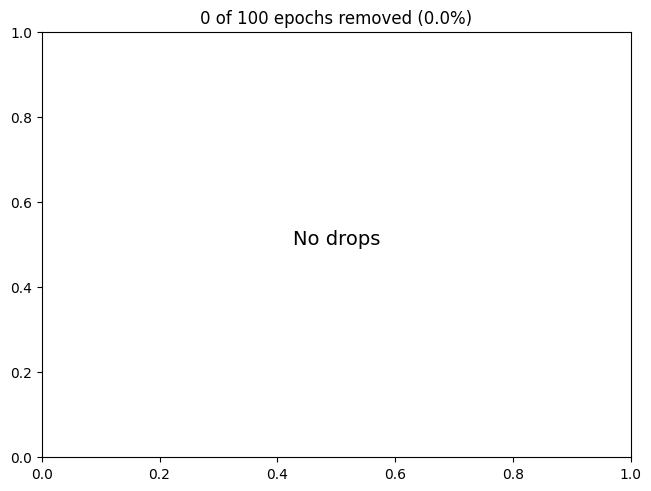

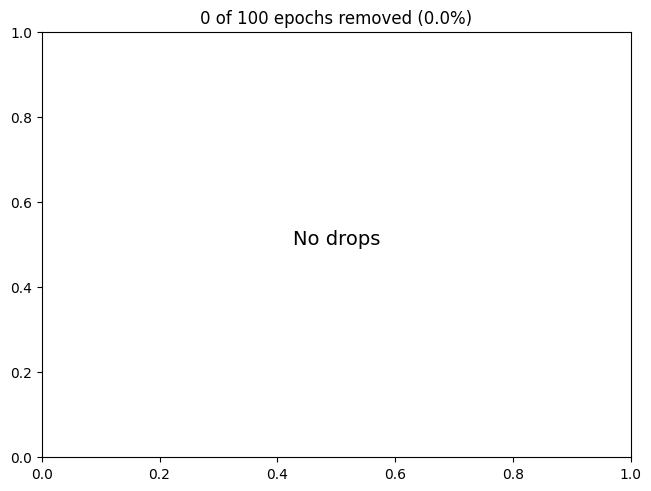

In [11]:
# Check how many epochs before rejection
print(f"Epochs before rejection: {len(epochs)}")

# Reject epochs exceeding 150 microvolts on any EEG channel
epochs.drop_bad(reject={'eeg': 150e-6})

# Check how many remain
print(f"Epochs after rejection: {len(epochs)}")

# See a summary of why epochs were dropped
epochs.plot_drop_log()

## Step 6 — Compute the ERP

We average across all 100 epochs to produce the ERP (Event-Related Potential).
Random noise averages out to zero across trials.
Any signal time-locked to the stimulus survives the averaging.

With synthetic random data, the ERP will be flat — this is correct.
The workflow is identical to what we'll use on real EEG data.

In [13]:
# Average across all epochs → ERP
evoked = epochs.average()

print(evoked)
print(f"\nNumber of epochs averaged: {evoked.nave}")
print(f"ERP shape: {evoked.data.shape}")

<Evoked | 'stimulus' (average, N=100), -0.2 – 0.8 s, baseline -0.2 – 0 s, 64 ch, ~565 kB>

Number of epochs averaged: 100
ERP shape: (64, 1001)


## Step 7 — Visualize the ERP

In [17]:
import matplotlib
import os
matplotlib.use('Agg')

# Build path
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
figures_dir = os.path.join(notebook_dir, '..', 'figures')
os.makedirs(figures_dir, exist_ok=True)

# Butterfly plot — all 64 channels overlaid
fig1 = evoked.plot(show=False, titles='ERP — Synthetic Data')
fig1.savefig(os.path.join(figures_dir, 'erp_butterfly.png'),
             dpi=150, bbox_inches='tight')
plt.close('all')

print(f"Butterfly plot saved to: {figures_dir}")
print("Note: Topomaps require real electrode positions.")
print("We will add them in the Wakeman-Henson replication.")

Butterfly plot saved to: C:\Users\ASUS\neuro-eeg-pipeline\..\figures
Note: Topomaps require real electrode positions.
We will add them in the Wakeman-Henson replication.


## Step 8 — Save the Epochs

Saving cleaned epochs means we never need to re-run preprocessing.
This is standard practice in reproducible neuroscience workflows.

In [20]:
import os

# Build path relative to notebook location
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
data_dir = os.path.join(notebook_dir, '..', 'data')
os.makedirs(data_dir, exist_ok=True)

# Save epochs
save_path = os.path.join(data_dir, 'synthetic_epochs-epo.fif')
epochs.save(save_path, overwrite=True)

# Verify by reloading
epochs_check = mne.read_epochs(save_path)
print(f"Reloaded successfully: {len(epochs_check)} epochs")
print(f"Saved to: {save_path}")

Reading C:\Users\ASUS\neuro-eeg-pipeline\..\data\synthetic_epochs-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -200.00 ...     800.00 ms
        0 CTF compensation matrices available
Not setting metadata
100 matching events found
No baseline correction applied
0 projection items activated
Reloaded successfully: 100 epochs
Saved to: C:\Users\ASUS\neuro-eeg-pipeline\..\data\synthetic_epochs-epo.fif
